# **Dados e Aprendizagem Automática** 

## **Random Forest - Tratamento 1**
Nesta primeira abordagem, optámos por uma estratégia de limpeza e transformação mais simplificada. Iniciámos pelo tratamento dos valores em falta, preenchemos as lacunas nas variáveis categóricas e no _target_ com "None". Embora a coluna 'RECORD_DATE' tenha sido convertida para formato de data, esta acabou por ser removida. Ao nível do texto, aplicámos uma função de redução drástica à 'AVERAGE_CLOUDINESS' (agrupando apenas em "céu limpo" ou "nublado") e, após um mapeamento inicial, optámos por remover a coluna 'AVERAGE_RAIN', juntamente com as colunas redundantes 'CITY_NAME' e 'AVERAGE_PRECIPITATION'. Por fim, aplicámos Label Encoding às variáveis categóricas e Ordinal Encoding à variável alvo, convertendo as categorias em valores numéricos sequenciais em vez de utilizar codificação binária.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### **Preparation**
**Load the CSVs**

In [ ]:
df_train = pd.read_csv('../../Datasets/training_data.csv', encoding='latin-1')
df_test = pd.read_csv('../../Datasets/test_data.csv', encoding='latin-1')

**Missing values**

In [3]:
"""
Fill MV on target
"""
#df_train["AVERAGE_SPEED_DIFF"] = df_train["AVERAGE_SPEED_DIFF"].fillna("Low")
#df_train = df_train.dropna(subset=["AVERAGE_SPEED_DIFF"])
df_train["AVERAGE_SPEED_DIFF"] = df_train["AVERAGE_SPEED_DIFF"].fillna("None")


In [4]:
df_train['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
céu claro            1582
céu pouco nublado     516
nuvens dispersas      459
nuvens quebrados      448
algumas nuvens        422
nuvens quebradas      416
céu limpo             153
tempo nublado          67
nublado                67
Name: count, dtype: int64

In [5]:
df_train['AVERAGE_RAIN'].value_counts()

AVERAGE_RAIN
chuva fraca                    261
chuva moderada                 153
chuva leve                      45
aguaceiros fracos               38
chuva                           30
aguaceiros                      11
chuva forte                      8
trovoada com chuva leve          7
chuvisco fraco                   5
chuva de intensidade pesado      2
chuva de intensidade pesada      1
trovoada com chuva               1
chuvisco e chuva fraca           1
Name: count, dtype: int64

In [6]:
df_train['LUMINOSITY'].value_counts()

LUMINOSITY
LIGHT        3293
DARK         3253
LOW_LIGHT     266
Name: count, dtype: int64

In [7]:
df_test['LUMINOSITY'].value_counts()

LUMINOSITY
DARK         730
LIGHT        725
LOW_LIGHT     45
Name: count, dtype: int64

In [8]:
print(df_train.isna().sum())

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF            0
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64


In [9]:
df_test['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
cï¿½u claro            345
cï¿½u pouco nublado    109
algumas nuvens          98
nuvens quebrados        96
nuvens quebradas        95
nuvens dispersas        94
cï¿½u limpo             27
tempo nublado           20
nublado                 17
Name: count, dtype: int64

**Redundant values**

In [10]:
# Clean function
def clean_categorical_text(df):

    correcoes_erros = {
        'cï¿½u': 'ceu',    
        'c\u00e9u': 'ceu', 
        'c\u00fa': 'ceu',  
        'c\u00fau': 'ceu', 
        'céu': 'ceu'
    }
    
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(correcoes_erros, regex=True)

    cloud_map = {
        'ceu claro': 'ceu_claro',
        'ceu limpo': 'ceu_claro',

        'ceu pouco nublado': 'pouco_nublado',
        'nuvens dispersas': 'pouco_nublado',
        'algumas nuvens': 'pouco_nublado',

        'nuvens quebrados': 'nublado', 
        'nuvens quebradas': 'nublado',
        'tempo nublado': 'nublado',
        'nublado': 'nublado',
    }
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].astype(str).replace(cloud_map, regex=True)
    
    df['AVERAGE_CLOUDINESS'] = df['AVERAGE_CLOUDINESS'].replace('nan', 'unknown_cloudiness')
    
    
    rain_map = {
        'chuva fraca': 'chuva_fraca',
        'chuva leve': 'chuva_fraca',
        'aguaceiros fracos': 'chuva_fraca',
        'chuvisco fraco': 'chuva_fraca',
        'chuvisco e chuva fraca': 'chuva_fraca',
        'trovoada com chuva leve': 'chuva_fraca', 

        'chuva moderada': 'chuva_moderada',
        'chuva': 'chuva_moderada',
        'aguaceiros': 'chuva_moderada',
        'trovoada com chuva': 'chuva_moderada',

        'chuva forte': 'chuva_forte',
        'chuva de intensidade pesada': 'chuva_forte',
        'chuva de intensidade pesado': 'chuva_forte'
    }
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].replace(rain_map)
    df['AVERAGE_RAIN'] = df['AVERAGE_RAIN'].fillna('no_rain')
    
    #df["LUMINOSITY"] = df_train["LUMINOSITY"].replace("LOW_LIGHT", "LIGHT")
    
    return df

df_train = clean_categorical_text(df_train)
df_test = clean_categorical_text(df_test)

In [11]:
df_test['AVERAGE_CLOUDINESS'].value_counts()

AVERAGE_CLOUDINESS
unknown_cloudiness    599
ceu_claro             372
pouco_nublado         301
nublado               228
Name: count, dtype: int64

In [12]:
df_test['AVERAGE_RAIN'].value_counts()

AVERAGE_RAIN
no_rain           1360
chuva_fraca         93
chuva_moderada      47
Name: count, dtype: int64

**Handling categoric data**

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [14]:
"""
AVERAGE_RAIN
"""

le_rain = LabelEncoder()
df_train["AVERAGE_RAIN"] = le_rain.fit_transform(df_train["AVERAGE_RAIN"])
df_test["AVERAGE_RAIN"] = le_rain.transform(df_test["AVERAGE_RAIN"]) 


In [15]:
"""
AVERAGE_CLOUDINESS
"""
le_cloud = LabelEncoder()
df_train["AVERAGE_CLOUDINESS"] = le_cloud.fit_transform(df_train["AVERAGE_CLOUDINESS"])
df_test["AVERAGE_CLOUDINESS"] = le_cloud.transform(df_test["AVERAGE_CLOUDINESS"])


In [16]:
"""
LUMINOSITY
"""
le_lu = LabelEncoder()
df_train["LUMINOSITY"] = le_lu.fit_transform(df_train["LUMINOSITY"])
df_test["LUMINOSITY"] = le_lu.transform(df_test["LUMINOSITY"])


In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       6812 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   int64  
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       6812 non-null   int64  
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             6812 non-null   int64  
dtypes: float64(8), int64(3),

**Unique columns**

In [18]:
"""
AVERAGE_PRECIPITATION
"""
df_train.drop(columns=["AVERAGE_PRECIPITATION"],inplace=True)
df_test.drop(columns=["AVERAGE_PRECIPITATION"],inplace=True)

In [19]:
"""
city_name
"""
df_train.drop(columns=["city_name"],inplace=True)
df_test.drop(columns=["city_name"],inplace=True)

In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   record_date              6812 non-null   object 
 1   AVERAGE_SPEED_DIFF       6812 non-null   object 
 2   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 3   AVERAGE_TIME_DIFF        6812 non-null   float64
 4   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 5   LUMINOSITY               6812 non-null   int64  
 6   AVERAGE_TEMPERATURE      6812 non-null   float64
 7   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 8   AVERAGE_HUMIDITY         6812 non-null   float64
 9   AVERAGE_WIND_SPEED       6812 non-null   float64
 10  AVERAGE_CLOUDINESS       6812 non-null   int64  
 11  AVERAGE_RAIN             6812 non-null   int64  
dtypes: float64(7), int64(3), object(2)
memory usage: 638.8+ KB


**Dates**

In [21]:
df_train["record_date"] = pd.to_datetime(df_train["record_date"], errors="coerce")

In [22]:
df_train["record_date"]

0      2019-08-29 07:00:00
1      2018-08-10 14:00:00
2      2019-09-01 16:00:00
3      2019-02-26 11:00:00
4      2019-06-06 12:00:00
               ...        
6807   2019-02-23 09:00:00
6808   2019-06-08 18:00:00
6809   2018-10-02 04:00:00
6810   2019-01-30 01:00:00
6811   2019-06-15 21:00:00
Name: record_date, Length: 6812, dtype: datetime64[ns]

In [23]:
"""
For now will drop date column
"""
df_train.drop(columns=["record_date"], inplace=True)

**Relations**

<Axes: >

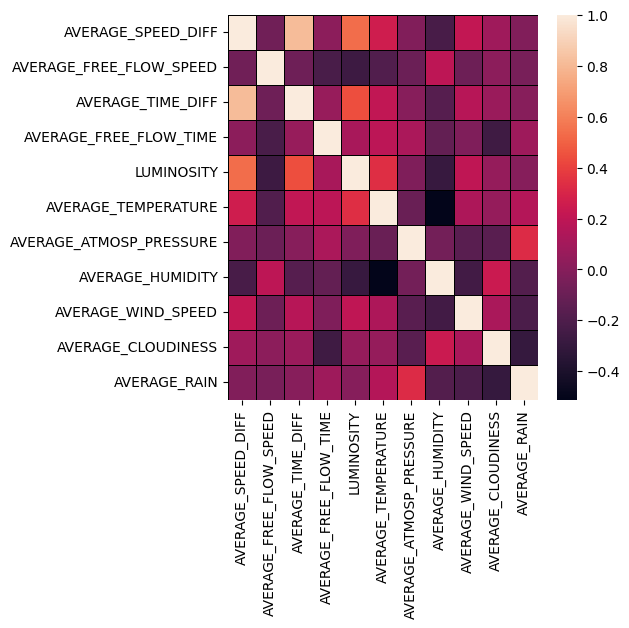

In [24]:

# Criar uma cópia apenas para análise
df_temp = df_train.copy()

""" le_speed = LabelEncoder()
df_temp["AVERAGE_SPEED_DIFF"] = le_speed.fit_transform(df_temp["AVERAGE_SPEED_DIFF"])
 """
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder(categories=[["None", "Low", "Medium", "High", "Very_High"]])

df_temp["AVERAGE_SPEED_DIFF"] = ord_encoder.fit_transform(df_temp[["AVERAGE_SPEED_DIFF"]])
df_temp["AVERAGE_SPEED_DIFF"] = df_temp["AVERAGE_SPEED_DIFF"].astype(int)

fig = plt.figure(figsize=(5,5))
corre = df_temp.corr(method='pearson')
sns.heatmap(corre,linecolor='black', linewidths=0.5)

In [25]:
#sns.pairplot(df_temp, hue="AVERAGE_SPEED_DIFF")

### **Modeling**

Select features and target

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

In [27]:
X_train = df_train.drop(columns=["AVERAGE_SPEED_DIFF"])
y_train = df_train["AVERAGE_SPEED_DIFF"]

In [28]:
X_test = df_test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

**Validation Block**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Cópias
X_val_copy = X_train.copy()
y_val_copy = y_train.copy()

# criar conjunto de val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_val_copy, y_val_copy, test_size=0.2, random_state=2022, stratify=y_val_copy
)

# Treinar modelo só para validar
clf_val = RandomForestClassifier(random_state=2022)
clf_val.fit(X_tr, y_tr)

# Prever na validação
val_preds = clf_val.predict(X_val)

# Mostrar accuracy
print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("\nClassification Report:\n", classification_report(y_val, val_preds))


Validation Accuracy: 0.7960381511371973

Classification Report:
               precision    recall  f1-score   support

        High       0.78      0.75      0.76       213
         Low       0.69      0.70      0.69       284
      Medium       0.77      0.76      0.77       330
        None       0.88      0.90      0.89       440
   Very_High       0.83      0.81      0.82        96

    accuracy                           0.80      1363
   macro avg       0.79      0.79      0.79      1363
weighted avg       0.80      0.80      0.80      1363



**Prediction**

Predict on test set

In [30]:
clf = RandomForestClassifier(random_state=2022)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
preds = clf.predict(X_test)

Create csv

In [ ]:
submission = pd.DataFrame({
    "RowId": range(1, len(preds)+1),
    "Speed_Diff": preds
})

submission.to_csv("../../results/RandomForest/rf1.csv", index=False)
submission.head()

,RowId,Speed_Diff
0,1,None
1,2,Medium
2,3,None
3,4,High
4,5,Low
